Install PyUUl, important necessary libraries (edit here)

In [2]:
# Need PyUUL to build voxel-based tensor representations
# pip install pyuul

# Import necessary libraries for voxelization
from pyuul import VolumeMaker # the main PyUUL module
from pyuul import utils # the PyUUL utility module
import time,os,urllib # some standard python modules we are going to use
import torch.nn.functional as F
import torch
import numpy as np
import torch.nn.utils.rnn
from torch.nn.utils.rnn import pad_sequence
import pyvista as pv

In [ ]:
def Voxelize(file_path:str): # - Takes in PDB in as an argument (or uses file path to already downloaded PDB files)

    # Fetch PDB files (either by link, or by uncompressing downloaded PDB files)
    # os.mkdir('exampleStructures')
    # urllib.request.urlretrieve('http://files.rcsb.org/download/101M.pdb', 'exampleStructures/101m.pdb')
    # urllib.request.urlretrieve('http://files.rcsb.org/download/5BMZ.pdb', 'exampleStructures/5bmz.pdb')
    # urllib.request.urlretrieve('http://files.rcsb.org/download/5BOX.pdb', 'exampleStructures/5box.pdb')


    # Grab information needed for voxel object
    coords, atname = utils.parsePDB(file_path) # get coordinates and atom names
    atoms_channel = utils.atomlistToChannels(atname) # calculates the corresponding channel of each atom
    radius = utils.atomlistToRadius(atname) # calculates the radius of each atom
    
    # Calculate padding needed for each dimensions
    # pad_sequence(coords,batch_first=True)
    
    # ISSUE: 
    #   *Supposedly* I need to center coordinates of each protein.
    #    However, I haven't been able to get it to work without bloating the output dimension by 8-9x.
    #    Will focus my attention elsewhere for the time being

    # Create VoxelsObject to create a voxel representation
    device = "cpu" # runs the volumes on CPU, use "cuda" for hardware
    
    VoxelsObject = VolumeMaker.Voxels(device=device,sparse=True)

    # Move everything to the right device
    coords = coords.to(device)
    radius = radius.to(device)
    atoms_channel = atoms_channel.to(device)

    # We move our tensor to the current accelerator if available
    # if torch.accelerator.is_available():
    #     VoxelsObject = VolumeMaker.Voxels(device=torch.accelerator.current_accelerator(),sparse=True)
    #     coords = coords.to(torch.accelerator.current_accelerator())
    #     radius = radius.to(torch.accelerator.current_accelerator())
    #     atoms_channel = atoms_channel.to(torch.accelerator.current_accelerator())

    # Make Voxel representation
    VoxelRepresentation = VoxelsObject(coords, radius, atoms_channel,resolution=1)
    
    return VoxelRepresentation


file_path = "Sample_Proteins/"
voxel_rep = Voxelize(file_path)
# voxel_rep.to("cpu")
print(voxel_rep.size())
print(voxel_rep)

torch.Size([10, 6, 73, 70, 120])
tensor(indices=tensor([[ 0,  0,  0,  ...,  9,  9,  9],
                       [ 0,  0,  0,  ...,  5,  5,  5],
                       [ 4,  4,  4,  ..., 30, 30, 30],
                       [22, 22, 22,  ..., 16, 17, 18],
                       [16, 17, 18,  ..., 34, 33, 34]]),
       values=tensor([9.5942e-05, 4.1866e-04, 6.8148e-05,  ...,
                      1.7670e-03, 2.4046e-04, 1.2805e-04]),
       size=(10, 6, 73, 70, 120), nnz=329240, layout=torch.sparse_coo)


Visualizing the voxel-based tensor representations. Using PyVista.

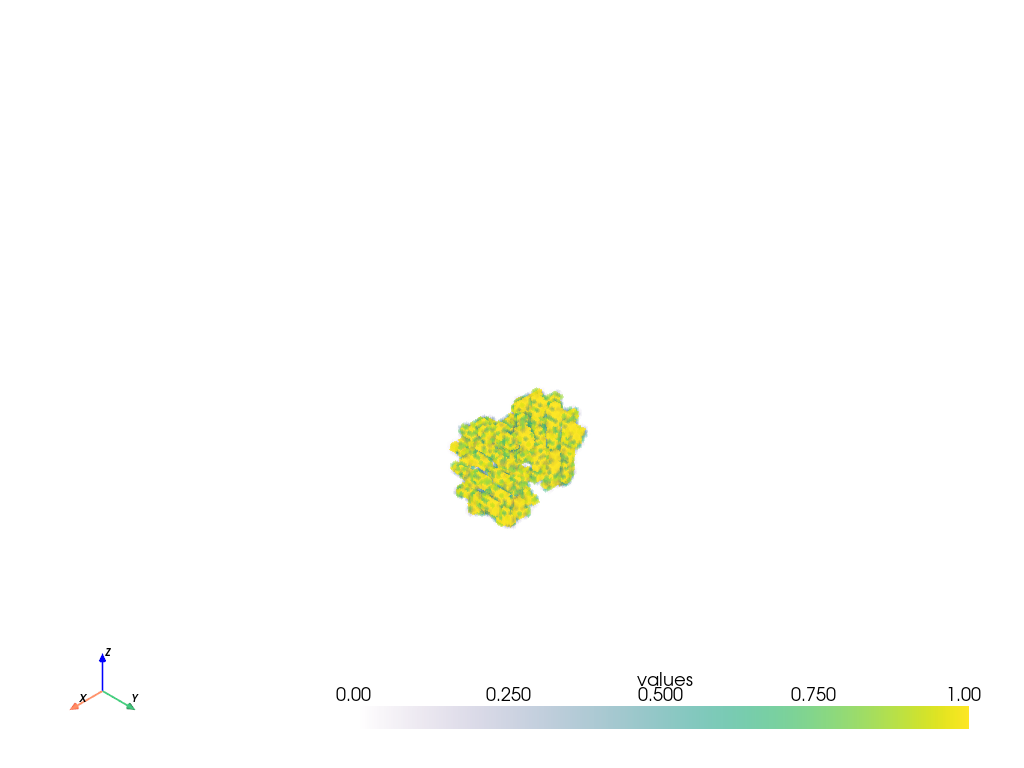

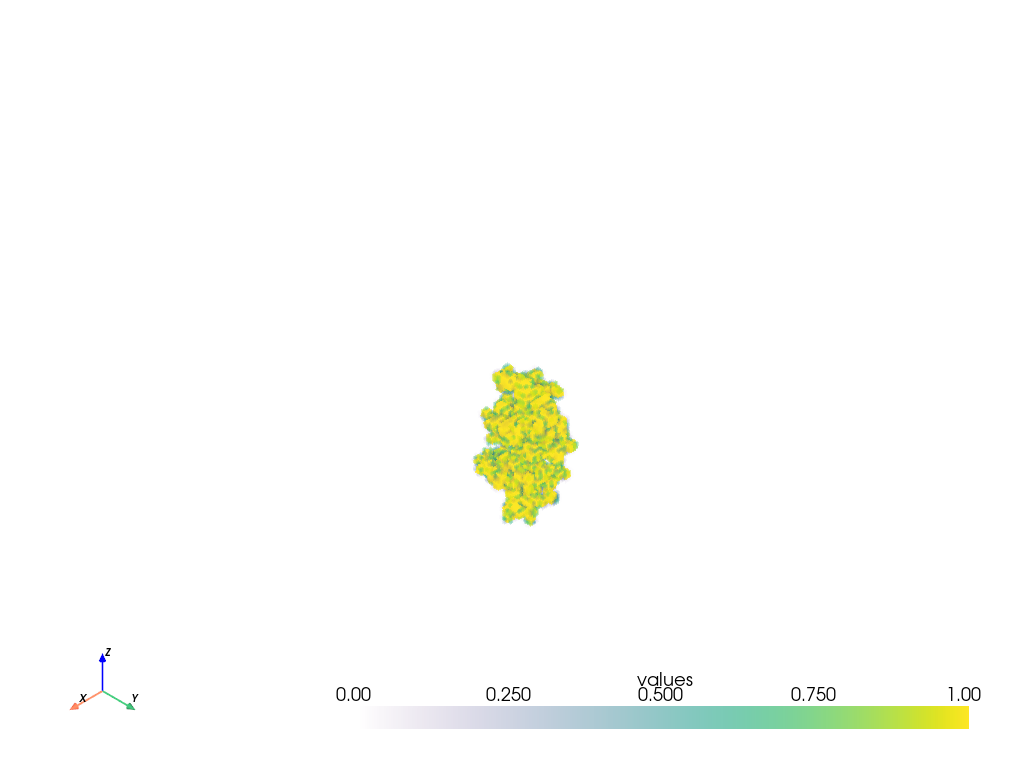

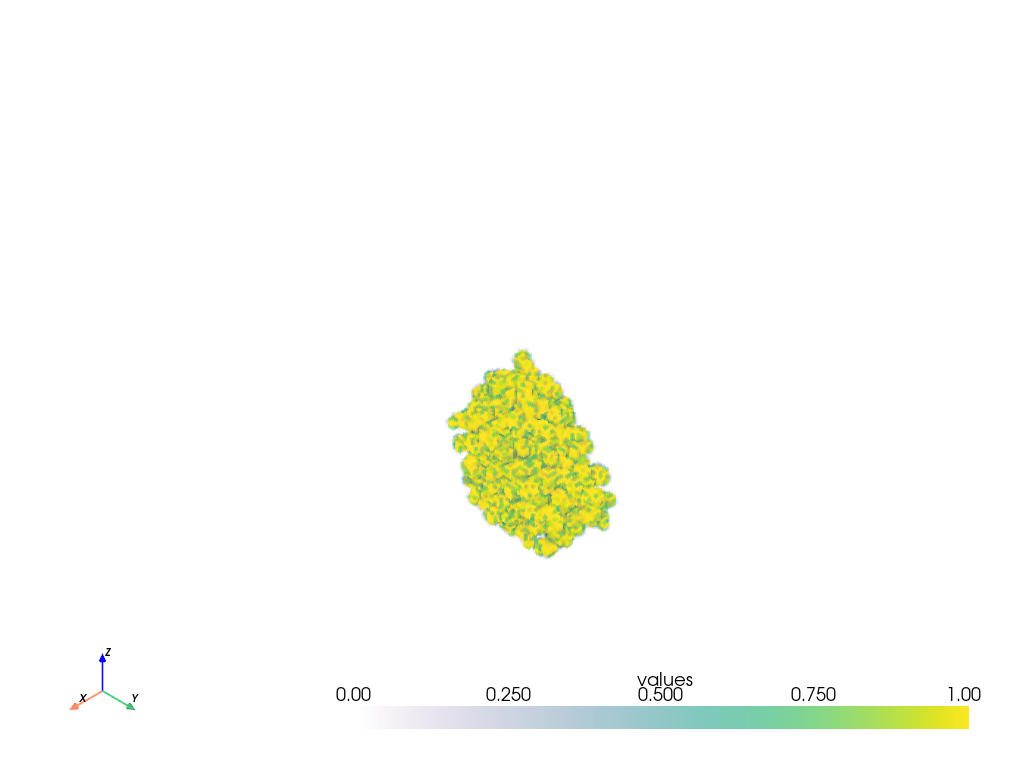

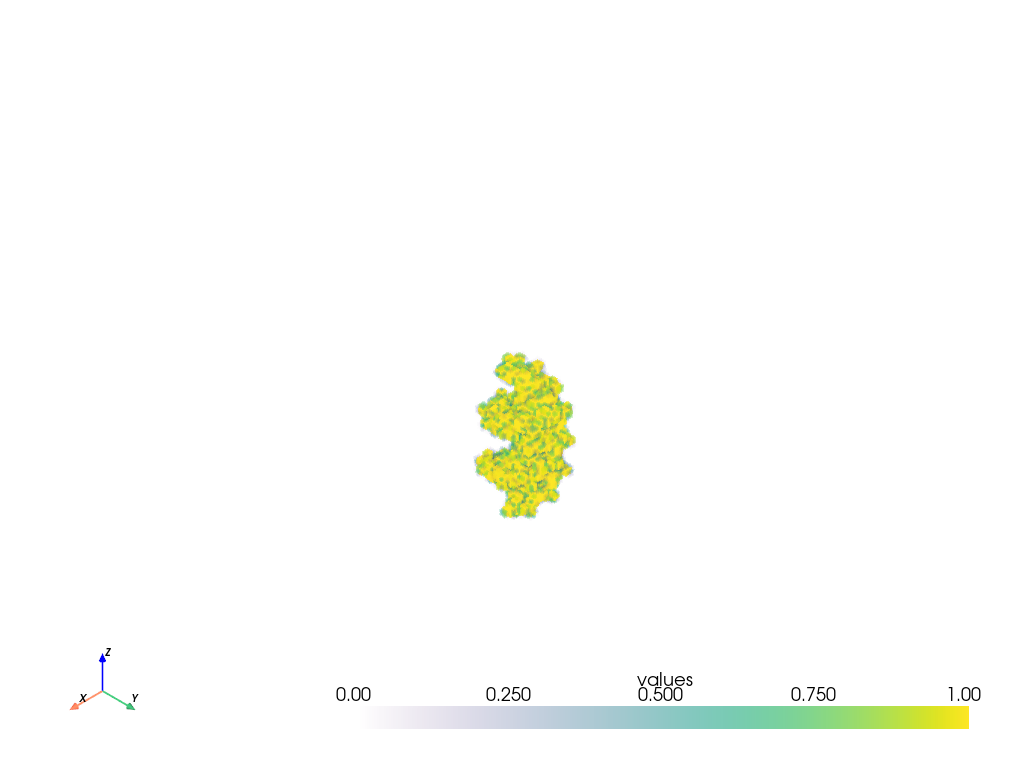

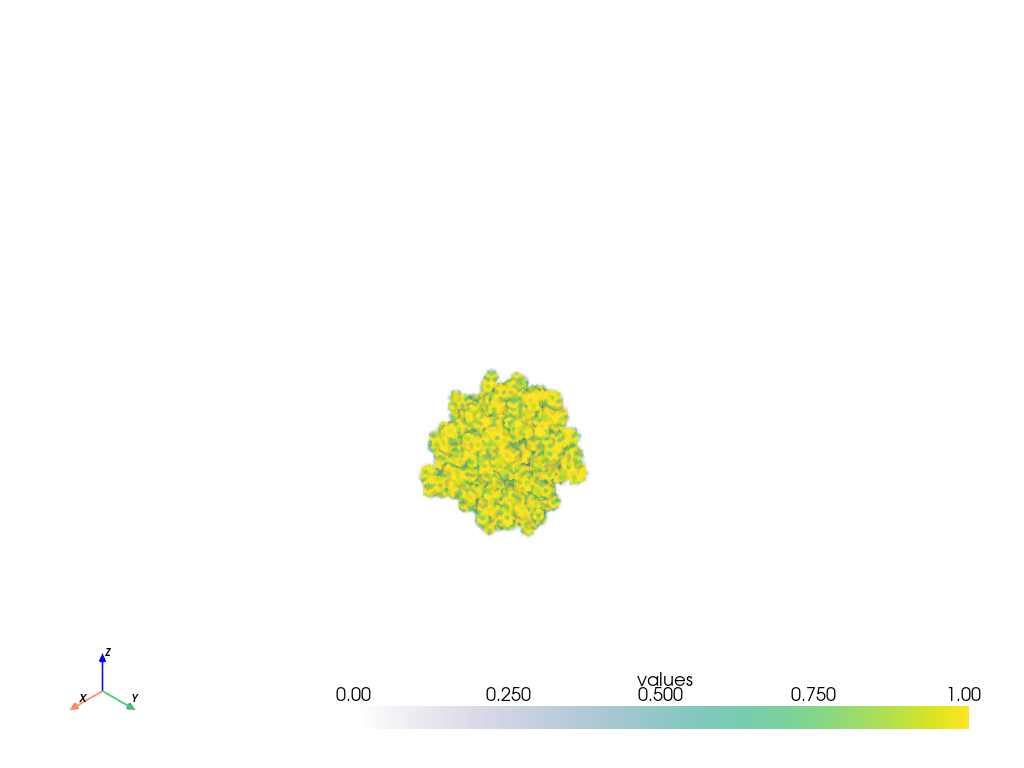

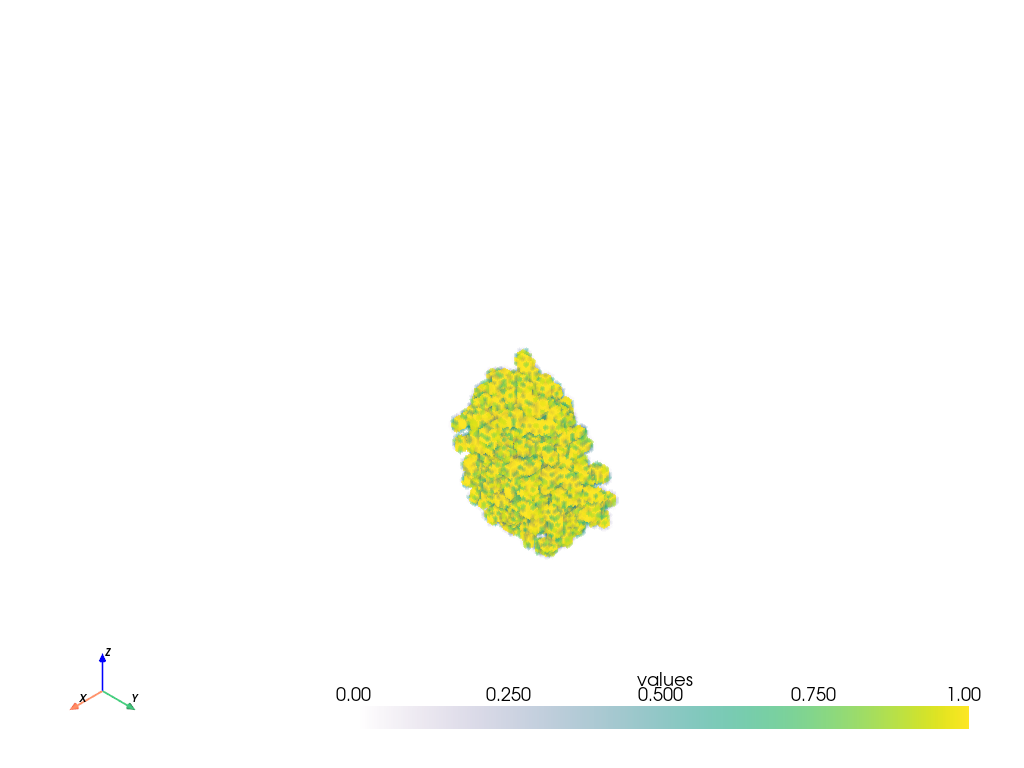

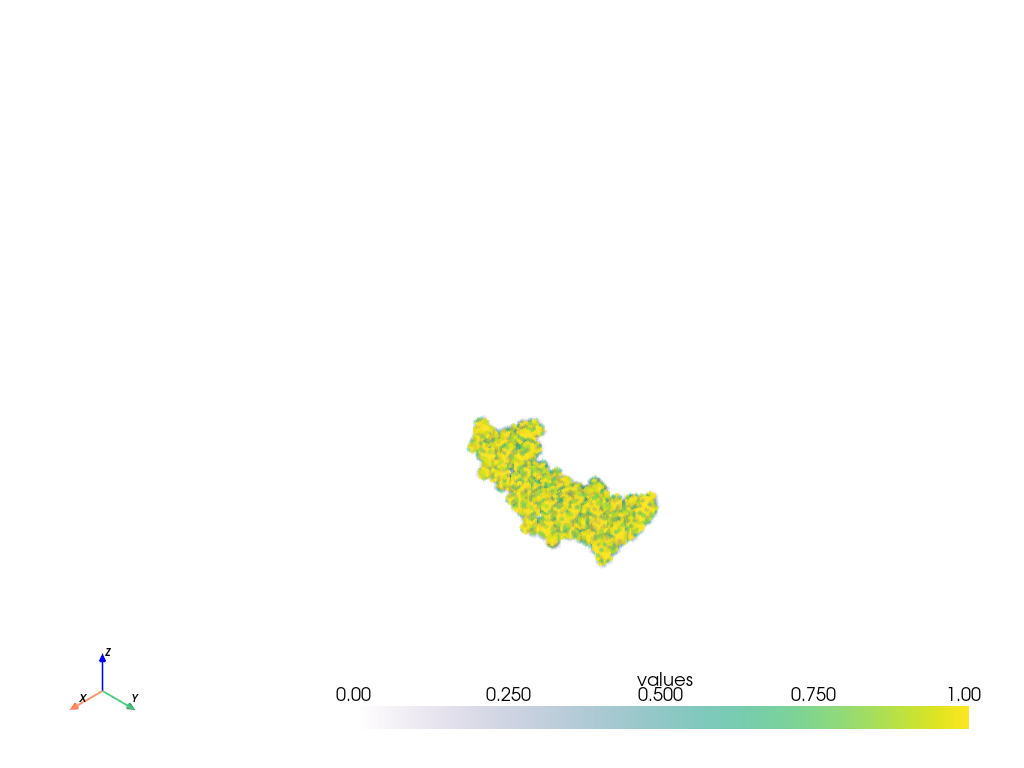

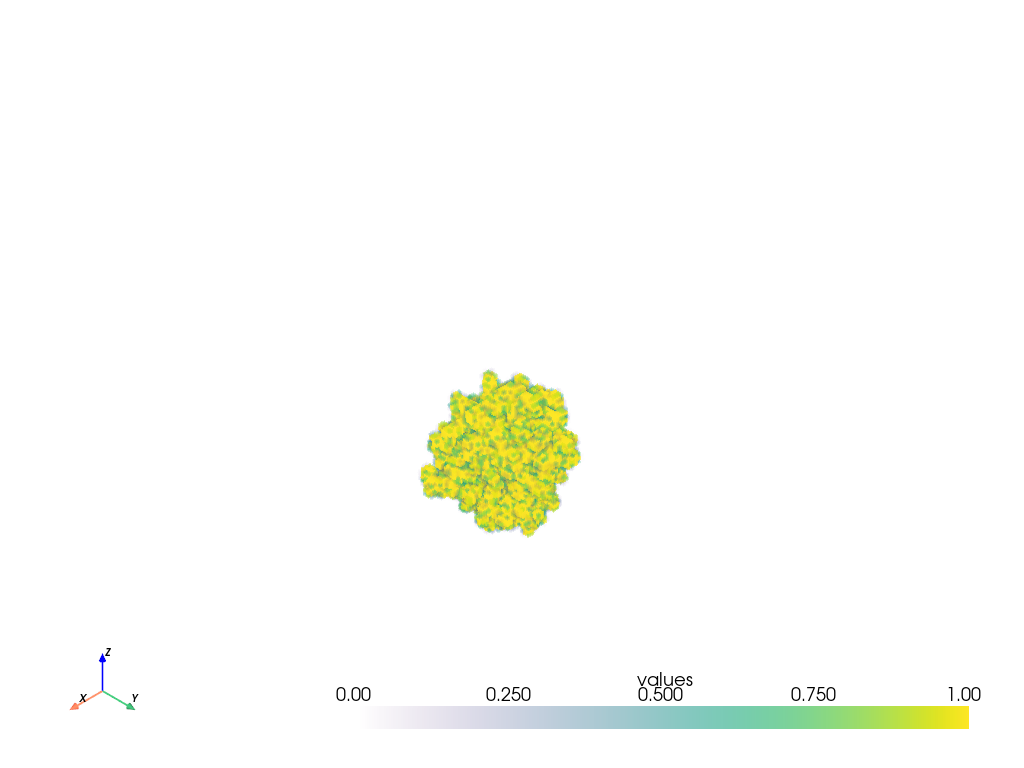

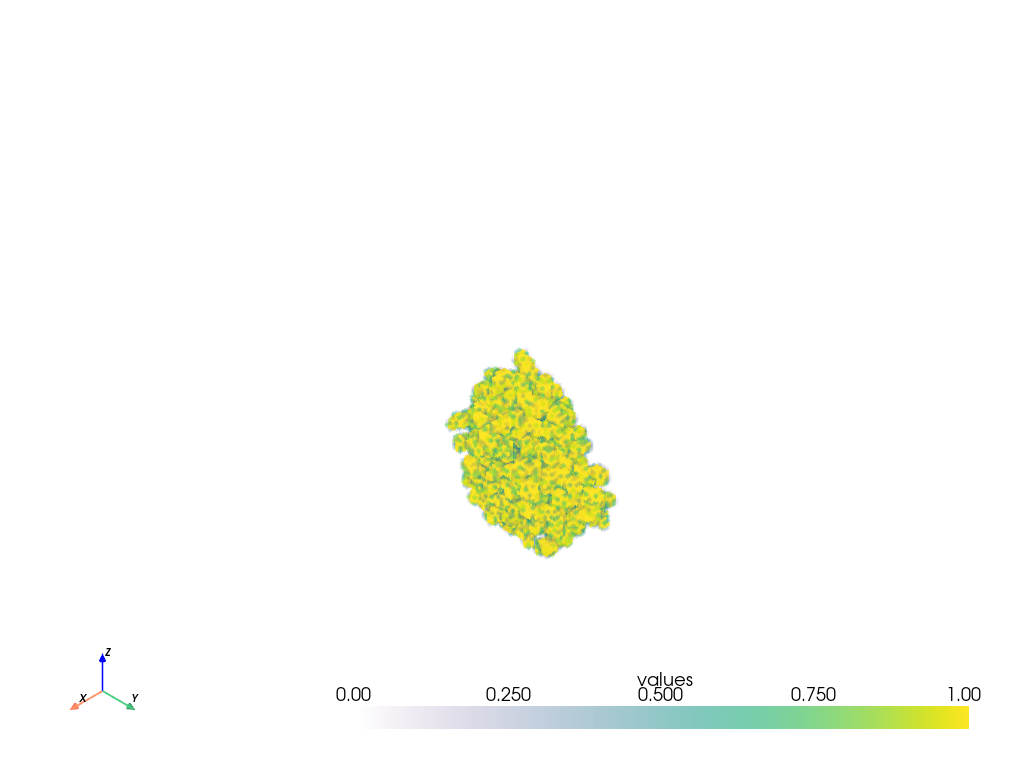

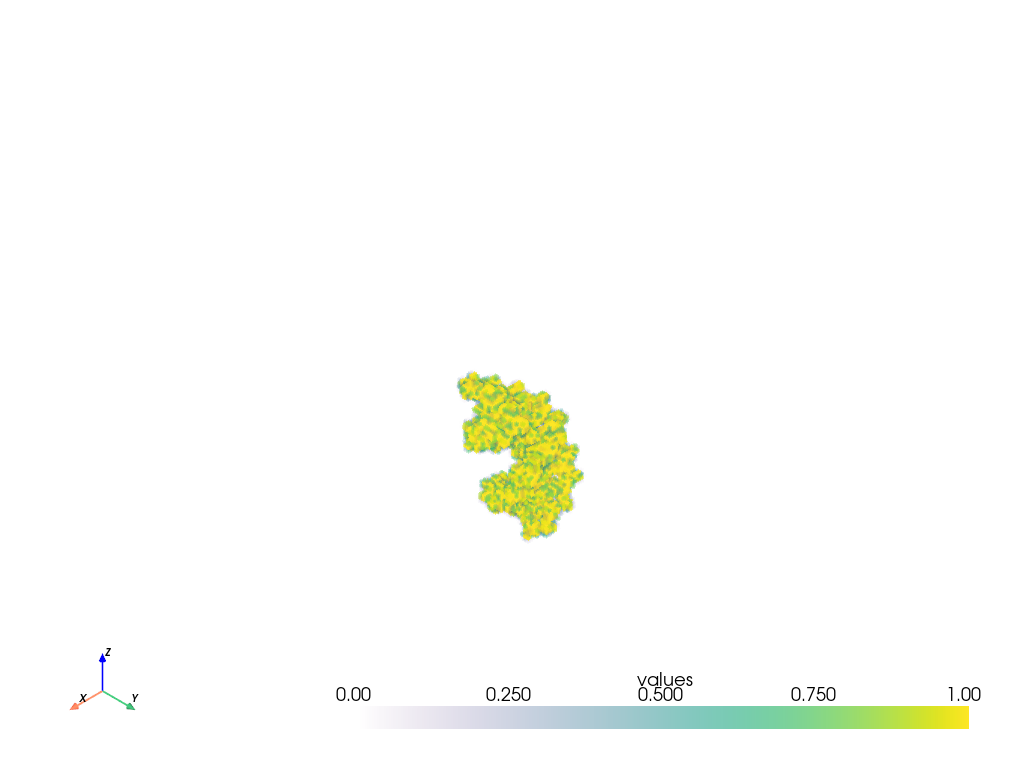

In [53]:
# [batch_size, channels, Depth, Height, Width]
for i in range(voxel_rep.shape[0]):
    protein = voxel_rep[i]
    protein = protein.to_dense().max(axis=0).values

    array = protein.numpy()
    grid = pv.wrap(array) # Automatically recognizes as a dataset
    grid.plot(jupyter_backend="static",volume=True)


DataSets and DataLoader 

In [21]:
class CustomPDBDataset(Dataset):
    # We implement torch.util.data.Dataset abstract class
    # Optionally implements:
    # __getitem()__ function: 
    # __len__() function: Use "os" module to count number of PDB files inside passed directory
    # __getitems() function: 
    # __init__ function
    #
    # arguments: PDB file dir, 
    # review later: transform, target_transform
    #  
    # 
    pass

# Preparing our data for training, example:
# from torch.utils.data import DataLoader

# Mini-batches = How many pieces of data to work on in parallel

# train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
# test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

NameError: name 'Dataset' is not defined

In [1]:
print("hello")

hello


Scaffolding Neural Network Class

In [ ]:
# example defining class NeuralNetwork(nn.Module):
class NeuralNetwork(nn.Module):
    def __init__(self):  # initialize nn layers 
            super().__init__()
            self.flatten = nn.Flatten() # flatten object 
            self.linear_relu_stack = nn.Sequential(
                # first layer 
                nn.Linear(28*28,512), #dimensional size of data
                nn.ReLU(), #unsure but acts as activation function
                # second layer repeat first
                # end with nn.Linear(28*28,512),

        )


        
    def forward(self, x): #  pass input through layers, but unsure of overall function
        x = self.flatten(x) 
        logits = self.linear_relu_stack(x)
        return logits # return x 


In [ ]:
model = NeuralNetwork().to(device) #creates an instance of nn and moves to device
print(model) #prints the model's structure, so returns in/out features and bias

Need to execute model's forward function w/o directly calling it
(will add further notes)

In [ ]:
# example (will add more notes)
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Note: example takes sample of 3 28x28 images
input_image = torch.rand(3,28,28)
print(input_image.size())

Flatten Layer: convert tensors into 

In [ ]:
# example converts 2D 28x28 image into an array of 784 pixel values 
flatten = nn.Flatten()
flat_image = flatten(input_image)
print(flat_image.size())
# essentially flattens a contiguous range of dim into a tensor

Linear layer: operation that applies linear transformation using stored weights/biases (need further explanation)

In [ ]:
#example 
layer1 = nn.Linear(in_features=28*28, out_features=20)
# args: in features = size of each input sample & same with out features 
hidden1 = layer1(flat_image)
print(hidden1.size())

Softmax layer: last layer in a nn, returns logits (raw values[0,1]) representing predicted probabilities 

In [ ]:
# example: 
softmax = nn.Softmax(dim=1) # dim parameter must = 1
pred_probab = softmax(logits) # predict probability

ReLu function = non linear activations to create in between mappings of models inputs/outputs (applied after linear layer)


Sequential function: stacks layers in a module (or container)